# Fashion MNIST classifier (CNN)

Trains a small convolutional network on Fashion MNIST and saves it for the Streamlit app in `../app`.

Run order: top to bottom. On a laptop CPU the whole notebook takes a couple of minutes.

## 1. Imports and seeds

In [1]:
import json
import os
import random

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

I0000 00:00:1790840242.240703     910 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790840242.286035     910 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790840243.897574     910 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Keras: 3.15.1


## 2. Load the data

Fashion MNIST ships with Keras: 60,000 training and 10,000 test images, each 28x28 grayscale, 10 classes.

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())
print("Train class counts:", np.bincount(y_train))

X_train: (60000, 28, 28) uint8
y_train: (60000,)
X_test:  (10000, 28, 28)
y_test:  (10000,)
Pixel range: 0 to 255
Train class counts: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


The classes are perfectly balanced (6,000 per class in train, 1,000 in test), so plain accuracy is a fair headline metric here.
Let's look at a few images.

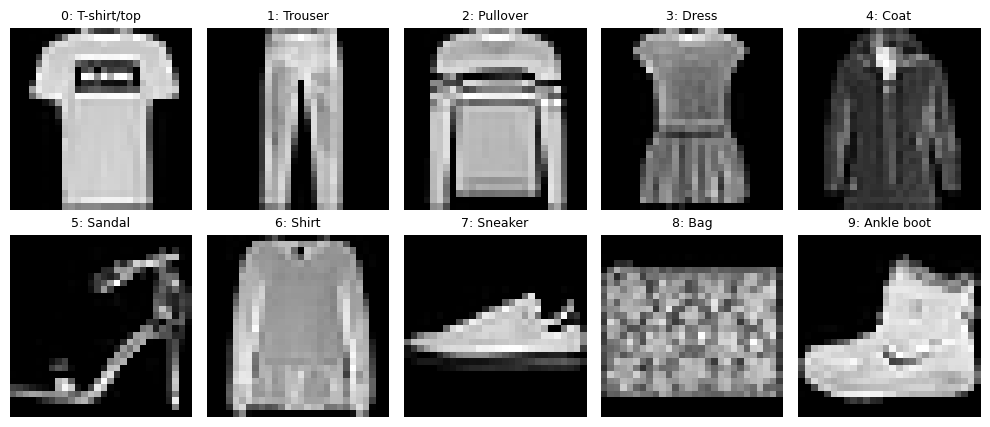

In [3]:
os.makedirs("../assets", exist_ok=True)

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for class_id, ax in enumerate(axes.ravel()):
    idx = np.where(y_train == class_id)[0][0]
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(f"{class_id}: {CLASS_NAMES[class_id]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../assets/sample_classes.png", dpi=130)
plt.show()

## 3. Preprocess

Two things:

1. Scale pixels from 0-255 to 0-1. Small, consistent input values keep the gradients well behaved.
2. Add a channel axis. `Conv2D` expects `(batch, height, width, channels)`, and a grayscale image has one channel, so `(60000, 28, 28)` becomes `(60000, 28, 28, 1)`.

The app must apply the exact same two steps at inference time. If it doesn't, accuracy drops quietly with no error message.

In [4]:
X_train = (X_train.astype("float32") / 255.0).reshape(-1, 28, 28, 1)
X_test = (X_test.astype("float32") / 255.0).reshape(-1, 28, 28, 1)

print("X_train:", X_train.shape, "range", X_train.min(), "to", X_train.max())
print("X_test: ", X_test.shape)

X_train: (60000, 28, 28, 1) range 0.0 to 1.0
X_test:  (10000, 28, 28, 1)


## 4. Model

Three conv layers with two max-pooling layers in between, then a dense head. The last layer outputs raw logits (no softmax), and the loss applies softmax internally with `from_logits=True`. That is numerically more stable than putting softmax in the model and computing the log of tiny probabilities.

In [5]:
model = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10),  # logits
    ],
    name="fashion_mnist_cnn",
)
model.summary()

Model: "fashion_mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train

- Adam optimizer, default learning rate.
- `SparseCategoricalCrossentropy` because the labels are integers (0-9), not one-hot vectors.
- 5 epochs, batch size 32 (the Keras default).
- 10% of the training set is held out as validation. The test set is not touched until the final evaluation, so the test number is an honest estimate and not something I tuned against.

In [6]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/5


1688/1688 - 24s - 14ms/step - accuracy: 0.8174 - loss: 0.5022 - val_accuracy: 0.8630 - val_loss: 0.3796


Epoch 2/5


1688/1688 - 40s - 24ms/step - accuracy: 0.8809 - loss: 0.3247 - val_accuracy: 0.8855 - val_loss: 0.3168


Epoch 3/5


1688/1688 - 40s - 24ms/step - accuracy: 0.8981 - loss: 0.2775 - val_accuracy: 0.8938 - val_loss: 0.2947


Epoch 4/5


1688/1688 - 21s - 13ms/step - accuracy: 0.9096 - loss: 0.2456 - val_accuracy: 0.8992 - val_loss: 0.2838


Epoch 5/5


1688/1688 - 41s - 24ms/step - accuracy: 0.9200 - loss: 0.2194 - val_accuracy: 0.9028 - val_loss: 0.2765


## 6. Evaluate on the test set

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     0.2861
Test accuracy: 0.8984


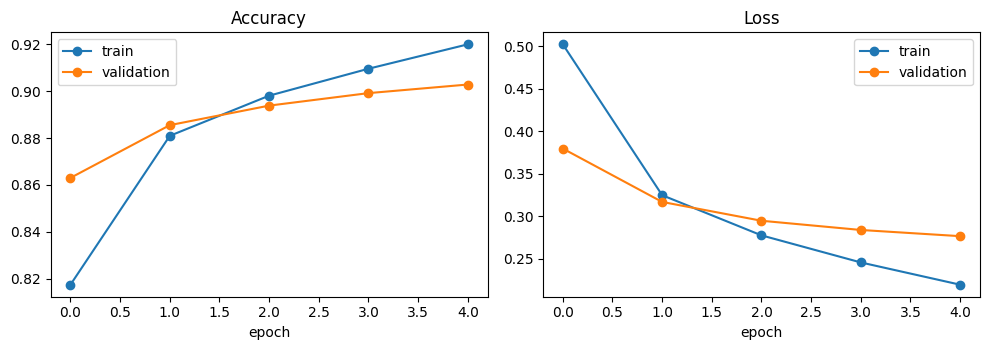

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

axes[0].plot(history.history["accuracy"], marker="o", label="train")
axes[0].plot(history.history["val_accuracy"], marker="o", label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], marker="o", label="train")
axes[1].plot(history.history["val_loss"], marker="o", label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("../assets/training_curves.png", dpi=130)
plt.show()

### Where does it go wrong?

Overall accuracy hides which classes get confused. The confusion matrix and per-class report show it.

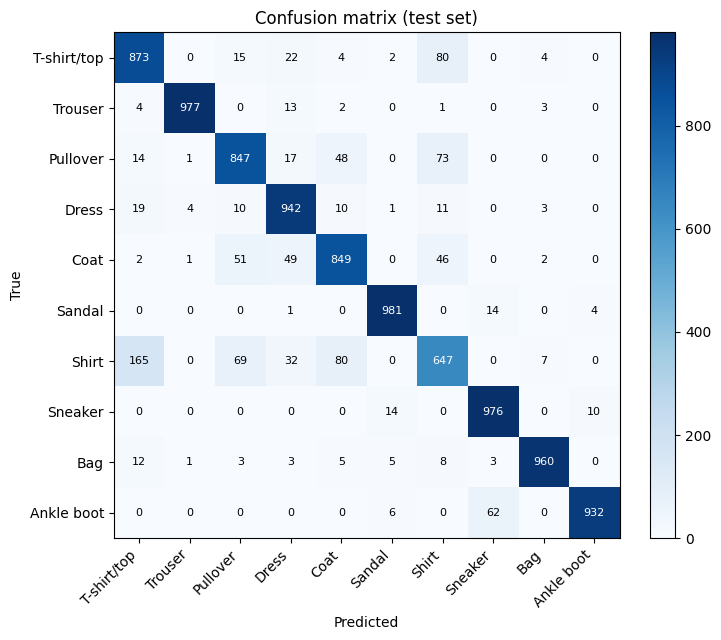

              precision    recall  f1-score   support

 T-shirt/top      0.802     0.873     0.836      1000
     Trouser      0.993     0.977     0.985      1000
    Pullover      0.851     0.847     0.849      1000
       Dress      0.873     0.942     0.906      1000
        Coat      0.851     0.849     0.850      1000
      Sandal      0.972     0.981     0.977      1000
       Shirt      0.747     0.647     0.693      1000
     Sneaker      0.925     0.976     0.950      1000
         Bag      0.981     0.960     0.970      1000
  Ankle boot      0.985     0.932     0.958      1000

    accuracy                          0.898     10000
   macro avg      0.898     0.898     0.897     10000
weighted avg      0.898     0.898     0.897     10000



In [9]:
logits = model.predict(X_test, verbose=0)
y_pred = np.argmax(logits, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("../assets/confusion_matrix.png", dpi=130)
plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

The usual suspects show up: Shirt, T-shirt/top, Pullover and Coat get mixed with each other. At 28x28 grayscale, a shirt and a T-shirt differ by a few pixels of sleeve.

In [10]:
# Most confused class pairs (off-diagonal counts)
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
pairs = np.dstack(np.unravel_index(np.argsort(-off_diag.ravel()), off_diag.shape))[0][:5]
for true_id, pred_id in pairs:
    print(f"{CLASS_NAMES[true_id]:>12} -> {CLASS_NAMES[pred_id]:<12} {off_diag[true_id, pred_id]} images")

       Shirt -> T-shirt/top  165 images
 T-shirt/top -> Shirt        80 images
       Shirt -> Coat         80 images
    Pullover -> Shirt        73 images
       Shirt -> Pullover     69 images


## 7. Save the model and the numbers

The `.keras` format is the current Keras 3 format. The old HDF5 (`.h5`) format still works but is considered legacy.

In [11]:
MODEL_PATH = "../app/trained_model/trained_fashion_mnist_model.keras"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
model.save(MODEL_PATH)

report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
metrics = {
    "seed": SEED,
    "epochs": 5,
    "batch_size": 32,
    "validation_split": 0.1,
    "train_accuracy_last_epoch": float(history.history["accuracy"][-1]),
    "val_accuracy_last_epoch": float(history.history["val_accuracy"][-1]),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "per_class_f1": {name: float(report[name]["f1-score"]) for name in CLASS_NAMES},
    "tensorflow": tf.__version__,
    "keras": keras.__version__,
}
with open("../assets/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved", MODEL_PATH, f"({os.path.getsize(MODEL_PATH) / 1e6:.2f} MB)")

Saved ../app/trained_model/trained_fashion_mnist_model.keras (1.16 MB)


## 8. Sanity check: reload and predict

If this disagrees with the in-memory model, something went wrong during save/load.

In [12]:
reloaded = keras.models.load_model(MODEL_PATH)
same = np.allclose(reloaded.predict(X_test[:200], verbose=0), logits[:200], atol=1e-5)
print("Reloaded model matches original on 200 test images:", same)

Reloaded model matches original on 200 test images: True
